# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SafeeAkmal/FlyRank-ML-internship-tasks/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

Ans: My lane's tasks revolve around scoring and classification. I will be working on CTR/Engagement oppurtunity scoring where my model will be detecting which pages are required for review only if they fall under a certain class or their score falls below a certain threshold.

To show the scoring aspect, we'll look at the distribution of CTR, which represents a continuous score. For the classification aspect, we'll examine the value counts of competition_level to see the different categories pages fall into.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Display descriptive statistics for 'ctr' to show scoring potential
print("Descriptive statistics for 'ctr' (scoring):")
display(df['ctr'].describe())

# Display value counts for 'competition_level' to show classification potential
print("\nValue counts for 'competition_level' (classification):")
display(df['competition_level'].value_counts())

Descriptive statistics for 'ctr' (scoring):


,ctr
count,30000.000000
mean,0.510733
std,3.279162
min,0.000000
25%,0.000000
50%,0.070000
75%,0.290000
max,100.000000



Value counts for 'competition_level' (classification):


,count
competition_level,
LOW,22896
HIGH,2658
MEDIUM,1836


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

Ans: I will be predicting whether a specific page with under-capture clicks or engagement is worth reviewing or not. The label would come from an observed pattern or set of outcomes. A single defined rule might not be true for all cases.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

# Identifying the primary target candidate (CTR) and its distribution
print("Analysis of Potential Target: CTR (Observed Outcome)")
display(df['ctr'].describe())

# Checking for potential categorical proxies or rules
print("\nAnalysis of Potential Proxy: Trend Direction (Categorical)")
display(df['trend_direction'].value_counts(dropna=False))

# Showing the relationship between a continuous score and a potential categorical rule
# For example, how CTR varies across different trend directions
display(df.groupby('trend_direction')['ctr'].mean().to_frame(name='mean_ctr_per_group'))

Analysis of Potential Target: CTR (Observed Outcome)


,ctr
count,30000.000000
mean,0.510733
std,3.279162
min,0.000000
25%,0.000000
50%,0.070000
75%,0.290000
max,100.000000



Analysis of Potential Proxy: Trend Direction (Categorical)


,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152


,mean_ctr_per_group
trend_direction,
down,0.324138
flat,1.376753
new,1.296521
stable,0.517321
up,0.565533


## 3. Success metric

*One metric you can defend. What number means 'good'?*

Since my task involves identifying a specific subset of pages for review, I would be looking for a metric that balances catching true opportunities (Recall) without overwhelming the reviewer with false alarms (Precision).


Percentage of rows flagged for review: 5.48%


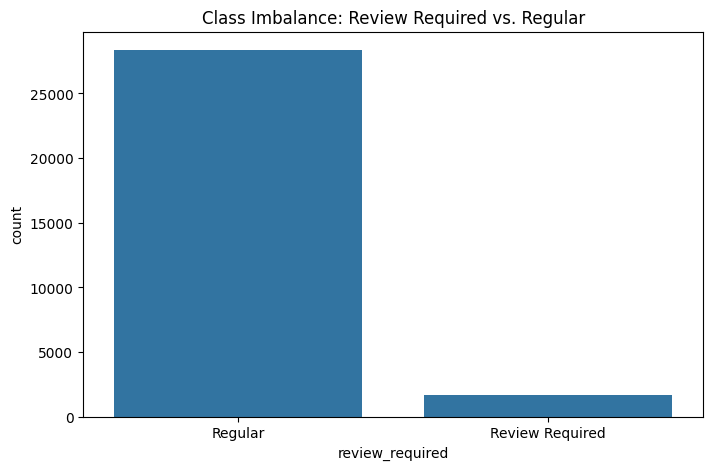

Because the 'Review Required' class is likely small, F1-Score is a better success metric than accuracy.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Define a heuristic for 'Review Required': Low CTR (< 0.1) but High Competition (> 0.6)
df['review_required'] = ((df['ctr'] < 0.1) & (df['competition'] > 0.6)).astype(int)

# Check the prevalence of the 'Review Required' class
prevalence = df['review_required'].mean()
print(f"Percentage of rows flagged for review: {prevalence:.2%}")

# Visualization of the trade-off
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='review_required', data=df)
plt.title('Class Imbalance: Review Required vs. Regular')
plt.xticks([0, 1], ['Regular', 'Review Required'])
plt.show()

print("Because the 'Review Required' class is likely small, F1-Score is a better success metric than accuracy.")


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?
*

Ans: In this dataset, one row = one unique content asset (identified by content_id). The analysis is performed at the individual page level to determine review priority.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Show one row to identify the unit of analysis
print("Example of one unit (one row):")
display(df.head(1))

# Confirming uniqueness of the content_id
total_rows = len(df)
unique_ids = df['content_id'].nunique()

print(f"\nTotal rows in dataset: {total_rows}")
print(f"Total unique content_ids: {unique_ids}")

if total_rows == unique_ids:
    print("\nConfirmed: One row = one unique content asset (page).")
else:
    print("\nNote: One row might represent a recurring observation of a content asset.")

Example of one unit (one row):


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,review_required
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4,0



Total rows in dataset: 30000
Total unique content_ids: 30000

Confirmed: One row = one unique content asset (page).


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

Ans: The relationship between metrics like search volume, competition, and CTR is non-linear and multidimensional. A fixed rule (e.g., if ctr < 0.1) misses high-potential pages that have high competition or emerging search volume trends. ML can weigh these factors simultaneously to find patterns that a nested if-statement would miss.

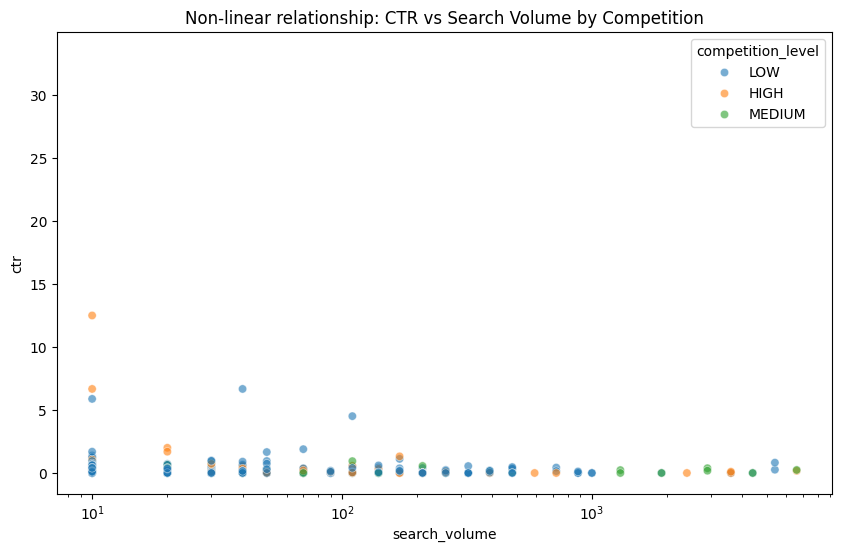

The scatter plot shows significant overlap across competition levels. A simple threshold on one variable doesn't cleanly separate the groups.


In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the messy overlap of features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(1000), x='search_volume', y='ctr', hue='competition_level', alpha=0.6)
plt.xscale('log')
plt.title('Non-linear relationship: CTR vs Search Volume by Competition')
plt.show()

print("The scatter plot shows significant overlap across competition levels. A simple threshold on one variable doesn't cleanly separate the groups.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.